<a href="https://colab.research.google.com/github/kenichiy19/1CCPK-MLAM/blob/main/Sprints/2026_2/Sprint%203/SPRINT_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrantes**

Felipe Pereira Restivo - RM: 570712

Gabriel Rodrigues Zappelloni - RM: 572060

Kenichi Caio Yamamoto - RM: 569815

Maykon de Lima Silva – RM: 574022

Rodger Costa Rios - RM: 571438

# **Biblioteca**

In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# **Código**

## Probabilidade acima da Mediana

In [3]:
df = pd.read_csv('/content/Salary_dataset.csv')

variavel = 'Salary'

mediana = df[variavel].median()
media = df[variavel].mean()
desvio_padrao = df[variavel].std()

probabilidade = 1 - stats.norm.cdf(mediana, media, desvio_padrao)

if probabilidade <= 0.10:
  classificacao = "Raro"
elif probabilidade < 0.50:
  classificacao = "Pouco provável"
elif probabilidade <= 0.90:
  classificacao = "Provável"
else:
  classificacao = "Quase certo"

print(f"Mediana: {mediana:.4f}")
print(f"Probabilidade de valores acima da mediana: {probabilidade * 100:.2f}%")
print(f"Classificação do evento: {classificacao}")

Mediana: 65238.0000
Probabilidade de valores acima da mediana: 65.27%
Classificação do evento: Provável


## Probabilidade no intervalo (média ± 2 desvios-padrão)

In [4]:
limite_inferior = media - (2 * desvio_padrao)
limite_superior = media + (2 * desvio_padrao)

prob_intervalo = stats.norm.cdf(limite_superior, media, desvio_padrao) - stats.norm.cdf(limite_inferior, media, desvio_padrao)

if prob_intervalo <= 0.10:
    classificacao = "Raro"
elif prob_intervalo < 0.50:
    classificacao = "Pouco provável"
elif prob_intervalo <= 0.90:
    classificacao = "Provável"
else:
    classificacao = "Quase certo"

print(f"Média: {media:.4f}")
print(f"Desvio-Padrão: {desvio_padrao:.4f}")
print(f"Limites do Intervalo: de ${limite_inferior:.2f} a ${limite_superior:.2f}")
print(f"Probabilidade no intervalo: {prob_intervalo * 100:.2f}%")
print(f"Classificação do evento: {classificacao}")

Média: 76004.0000
Desvio-Padrão: 27414.4298
Limites do Intervalo: de $21175.14 a $130832.86
Probabilidade no intervalo: 95.45%
Classificação do evento: Quase certo


## Modelagem com Regressão Linear

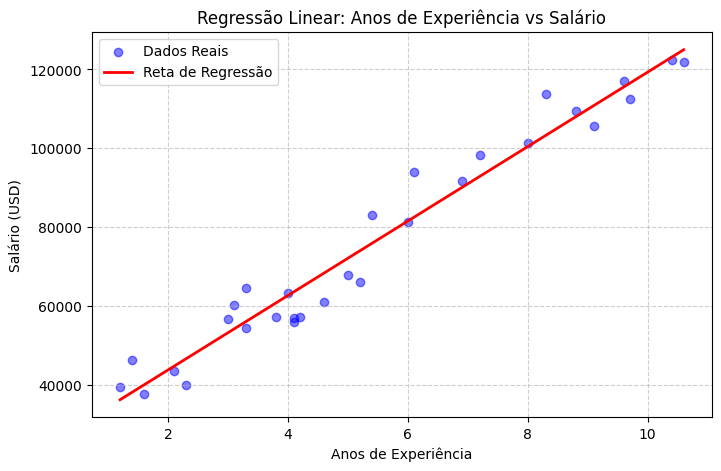

Coeficiente Angular (Inclinação): 9449.96
Coeficiente Linear (Interseção): 24848.20
Coeficiente de Determinação (R²): 0.9570


In [5]:
dados_limpos = df[['YearsExperience', 'Salary']].dropna()

X = dados_limpos[['YearsExperience']]
y = dados_limpos['Salary']

modelo = LinearRegression()
modelo.fit(X, y)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Dados Reais')
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Reta de Regressão')

plt.title('Regressão Linear: Anos de Experiência vs Salário')
plt.xlabel('Anos de Experiência')
plt.ylabel('Salário (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Coeficiente Angular (Inclinação): {modelo.coef_[0]:.2f}")
print(f"Coeficiente Linear (Interseção): {modelo.intercept_:.2f}")
print(f"Coeficiente de Determinação (R²): {modelo.score(X, y):.4f}")

### **Interpretação (Item C)**

**1. Coeficiente Angular (Inclinação)**:

Inclinação ($\beta_1 = 9.449,96$): Indica a taxa de variação marginal do modelo. Para cada $1$ ano adicional de experiência profissional, espera-se, em média, um incremento salarial de aproximadamente $9.449,96. O sinal positivo confirma a relação diretamente proporcional entre as variáveis.


**2. Coeficiente Linear (Interseção)**:

Interseção ($\beta_0 = 24.848,20$): Representa o valor base esperado da remuneração salarial quando a experiência profissional é nula ($\text{Anos de Experiência} = 0$). Embora profissionais em início de carreira raramente comecem com zero absoluto de tempo, o intercepto atua como o ponto de ancoragem inicial da reta de projeção.


**3. Coeficiente de Determinação**:

Qualidade do Ajuste ($R^2 = 0,9570$): O modelo demonstra que cerca de $95,70\%$ da variância dos salários é explicada unicamente pelo tempo de experiência acumulado. Trata-se de um ajuste linear expressivo, no qual os pontos observados situam-se muito próximos da reta teórica calculada.

## Relação entre Estatística e Aprendizado de Máquina

**Análise Exploratória e Seleção de Atributos**: A análise descritiva (média = 76.004,00; desvio padrão = 27.414,43) e o coeficiente de correlação de Pearson ($r = 0,9782$) atuaram como a fase de validação da pipeline. Como o tempo de experiência e o salário variam juntos de forma muito previsível, ficou provado que essa era a coluna certa para alimentar o modelo com as informações necessárias.

**Métricas e Avaliação de Desempenho**: O coeficiente de determinação ($R^2 = 0,9570$) funciona como a métrica de validação do ajuste. O resultado de 95,70% mostra que o gráfico capturou quase todo o padrão dos dados, garantindo previsões muito precisas e provando que o modelo não ficou simples demais a ponto de ignorar o comportamento real.

Análise Crítica e Escopo do Algoritmo: A interpretação da interseção ($\beta_0$) expõe o limite de aplicação do modelo. Como os dados da base começam a partir de $1,2$ anos de experiência, tentar prever o valor para $X = 0$ significa estimar algo fora do alcance dos dados estudados. Nesse contexto, o valor inicial serve apenas como um ajuste matemático para posicionar a reta corretamente no gráfico, e não para indicar um salário real para quem tem zero anos de casa.